In [1]:
import introns
import pandas as pd
import numpy as np
import importlib
importlib.reload(introns)
import matplotlib.pyplot as plt
from termcolor import colored
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# genome, genes = introns.create('fastas_and_gff/Alignments/test_edited_alignments_all_clean_3.fasta',
#                                'fastas_and_gff/Alignments/test_edited_alignments_all_clean_3.gff', 'manual')
# #genes, genome = introns.create_manual_from_gb('./fastas_and_gff/Alignments//alignments_all_clean_3_genes_only.gb')
# introns.add_manual_annotation_from_gb('./fastas_and_gff/Alignments/alignments_all_clean_3_genes_only.gb', genes)

genome, genes = introns.HELP_load_default_genome_genes()

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 117/117 [00:00<00:00, 412.42it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
predict_all_introns checkpoint 1/4
predict_all_introns checkpoint 2/4
predict_all_introns checkpoint 3/4
predict_all_introns checkpoint 4/4


In [3]:
introns_NK, introns_K, introns_I = [], [], []
genes_K, genes_NK, genes_both = [], [], []
exons = []

for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        intron.add_test_annotation()
        if intron.man_annotation == 'intron_NK':
            introns_NK.append(intron)
        if intron.man_annotation == 'intron_K':
            introns_K.append(intron)
        if intron.man_annotation == 'intron_I':
            introns_I.append(intron)
    for exon in gene_obj.exons:
        exons.append(exon)
print('Intron_NK', len(introns_NK))
print('Intron_K', len(introns_K))
print('intron_I', len(introns_I))
print(len(introns_I + introns_K + introns_NK))
print('exon', len(exons))

Intron_NK 325
Intron_K 348
intron_I 7
680
exon 1123


In [4]:
baseY = {'C', 'T'}
baseR = {'A', 'G'}

columns=['intron_obj', 'eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C', 'CAG - CGT', 'iY| e', 'i |Re', 'klasa']
introns_set = pd.DataFrame(columns = columns)

def compute_characteristics(intron):
    e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt = 0, 0, 0, 0, 0, 0, 0, 0

    c, a, t, g = False, False, False, False
    if intron.prev_exon.sequence[-1] in baseY:
        e_y_cnt = 1
    if intron.sequence[0] in baseR:
        i_r_cnt = 1
    if intron.sequence[3] == 'C' and intron.sequence[-6] == 'G':
        c = True
        i_C_cnt = 1
    if intron.sequence[4] == 'A' and intron.sequence[-7] == 'T':
        a = True
        i_A_cnt = 1
    if intron.sequence[5] == 'G' and intron.sequence[-8] == 'C':
        g = True
        i_G_cnt = 1
    if c and a and g:
        i_CAG_cnt = 1
    if intron.sequence[-1] in baseY:
        i_y_cnt = 1
    try:
        if intron.next_exon.sequence[0] in baseR:
            e_r_cnt = 1
    except IndexError:
        e_r_cnt = 0
        
    return e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt

introns_variants, true_classes = [], []
#introny niekonwencjonalne = 1
for intron in introns_NK:  
    intron_df = pd.DataFrame([[intron, *introns.compute_intron_characteristics(intron), 1]], columns=columns)
    #introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_set = pd.concat([introns_set, intron_df], ignore_index=True)
    introns_variants.append([introns.compute_intron_characteristics(i) for i in intron.variations+[intron]])
    true_classes.append(1)

#inne niż niekonwencjonalne = 0
for intron in introns_K+introns_I:
    intron_df = pd.DataFrame([[intron, *introns.compute_intron_characteristics(intron), 0]], columns=columns)
    #introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_set = pd.concat([introns_set, intron_df], ignore_index=True)
    introns_variants.append([introns.compute_intron_characteristics(i) for i in intron.variations])
    true_classes.append(0)
print(len(introns_variants), len(true_classes))
introns_obj = introns_set['intron_obj']
introns_set.drop('intron_obj', axis=1, inplace = True)
columns = introns_set.columns
introns_set = introns_set.astype('int')
print(introns_set)

/tmp/ipykernel_14972/456678409.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  introns_set = pd.concat([introns_set, intron_df], ignore_index=True)


680 680
     eY| i  e |Ri  C-G  A-T  G-C  CAG - CGT  iY| e  i |Re  klasa
0        1      1    1    1    1          4      3      2      1
1        1      1    1    1    1          6      2      4      1
2        1      1    0    1    0          1      1      1      1
3        1      1    1    1    1          8      2      2      1
4        1      1    1    1    1          9      1      3      1
..     ...    ...  ...  ...  ...        ...    ...    ...    ...
675      1      1    1    1    1          5      2      3      0
676      1      1    0    1    1          8      2      1      0
677      0      1    0    0    1          1      1      2      0
678      0      1    1    0    1          7      2      2      0
679      1      1    0    1    1          6      2      2      0

[680 rows x 9 columns]


In [5]:
baseY = {'C', 'T'}
baseR = {'A', 'G'}

columns=['intron_obj', 'eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C', 'CAG - CGT', 'iY| e', 'i |Re', 'klasa']
introns_set = pd.DataFrame(columns = columns)

def compute_characteristics(intron):
    e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt = 0, 0, 0, 0, 0, 0, 0, 0

    c, a, t, g = False, False, False, False
    if intron.prev_exon.sequence[-1] in baseY:
        e_y_cnt = 1
    if intron.sequence[0] in baseR:
        i_r_cnt = 1
    if intron.sequence[3] == 'C' and intron.sequence[-6] == 'G':
        c = True
        i_C_cnt = 1
    if intron.sequence[4] == 'A' and intron.sequence[-7] == 'T':
        a = True
        i_A_cnt = 1
    if intron.sequence[5] == 'G' and intron.sequence[-8] == 'C':
        g = True
        i_G_cnt = 1
    if c and a and g:
        i_CAG_cnt = 1
    if intron.sequence[-1] in baseY:
        i_y_cnt = 1
    if intron.next_exon.sequence[0] in baseR:
        e_r_cnt = 1
        
    return e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt

introns_variants, true_classes = [], []
#introny niekonwencjonalne = 1
for intron in introns_NK:  
    intron_df = pd.DataFrame([[intron, *introns.compute_intron_characteristics(intron), 1]], columns=columns)
    #introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_set = pd.concat([introns_set, intron_df], ignore_index=True)
    introns_variants.append([introns.compute_intron_characteristics(i) for i in intron.variations+[intron]])
    true_classes.append(1)

#inne niż niekonwencjonalne = 0
for intron in introns_K+introns_I:
    intron_df = pd.DataFrame([[intron, *introns.compute_intron_characteristics(intron), 0]], columns=columns)
    #introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_set = pd.concat([introns_set, intron_df], ignore_index=True)
    introns_variants.append([introns.compute_intron_characteristics(i) for i in intron.variations])
    #introns_variants = pd.concat([introns_variants]+pd.DataFrame([introns.compute_intron_characteristics(i) for i in intron.variations]))
    true_classes.append(0)
print(len(introns_variants), len(true_classes))
introns_obj = introns_set['intron_obj']
introns_set.drop('intron_obj', axis=1, inplace = True)
columns = introns_set.columns
introns_set = introns_set.astype('int')
print(introns_set)

/tmp/ipykernel_14972/1360995089.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  introns_set = pd.concat([introns_set, intron_df], ignore_index=True)


680 680
     eY| i  e |Ri  C-G  A-T  G-C  CAG - CGT  iY| e  i |Re  klasa
0        1      1    1    1    1          4      3      2      1
1        1      1    1    1    1          6      2      4      1
2        1      1    0    1    0          1      1      1      1
3        1      1    1    1    1          8      2      2      1
4        1      1    1    1    1          9      1      3      1
..     ...    ...  ...  ...  ...        ...    ...    ...    ...
675      1      1    1    1    1          5      2      3      0
676      1      1    0    1    1          8      2      1      0
677      0      1    0    0    1          1      1      2      0
678      0      1    1    0    1          7      2      2      0
679      1      1    0    1    1          6      2      2      0

[680 rows x 9 columns]


In [6]:
'''podzial intronow na 4 zbiory, zapisywanie zle zaklasyfikowanych'''
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import itertools



def add_misclassified_column(name,clf, introns_set=introns_set):
    n = int(len(introns_set)/4)
    i_s = introns_set.sample(frac=1)
    columns = list(i_s.columns)+['predprob', 'predclass']
    
    slices1 = list(range(0, len(i_s), n))[:-1]
    slices2 = slices1[1:]+[len(i_s)-1]
    print(slices1,slices2)
    newdfs=[]
    for start,end in zip(slices1, slices2):
        test = i_s[start:end]
        train = i_s.drop(list(range(start,end)))
        print(len(train), len(test))
        X_train, Y_train = train[train.columns[:-1]], train[train.columns[-1]]
        X_test, Y_test = test[test.columns[:-1]], test[test.columns[-1]]
        
        clf.fit(X_train, Y_train)
        predprob = clf.predict_proba(X_test)
        predclass = clf.predict(X_test)
        print(predprob[:,1].shape, predclass.shape, test.shape)
        #test['predprob']=predprob[:,1]
        #test['predclass']=predclass
        newdfs.append(test.assign(predprob=predprob[:,1], predclass=predclass))
    return pd.concat(newdfs, ignore_index=False)
'''
    print(name)
    predictions = np.empty((1,3))
    for ind, set1 in enumerate(sets):
        X_train, Y_train = rest_sets[rest_sets.columns[:-1]], rest_sets[rest_sets.columns[-1]]
        X_test, Y_test = set1[set1.columns[:-1]], set1[set1.columns[-1]]
        clf.fit(X_train, Y_train)
        predprob = clf.predict_proba(X_test)
        predclass = clf.predict(X_test)
        predictions = np.append(predictions, np.hstack((predprob, predclass)), axis=0)
    return predictions[1:]
'''

predictions = add_misclassified_column("gp", GaussianProcessClassifier(1.0 * RBF(1.0)), introns_set)
predictions

[0, 170, 340] [170, 340, 679]
510 170
(170,) (170,) (170, 9)
510 170
(170,) (170,) (170, 9)
341 339
(339,) (339,) (339, 9)


,eY| i,e |Ri,C-G,A-T,G-C,CAG - CGT,iY| e,i |Re,klasa,predprob,predclass
509,0,1,0,0,0,1,3,1,0,0.026591,0
303,1,1,0,1,1,3,2,1,1,0.959422,1
445,0,1,0,0,1,2,2,2,0,0.004443,0
327,0,1,0,0,1,2,1,1,0,0.005760,0
338,0,1,0,0,0,2,1,2,0,0.004226,0
...,...,...,...,...,...,...,...,...,...,...,...
158,1,1,0,1,1,4,2,1,1,0.950599,1
524,0,1,0,0,1,1,3,1,0,0.950599,1
396,0,1,0,0,1,1,1,2,0,0.950598,1
385,0,1,0,0,1,1,0,2,0,0.950598,1


In [7]:
wrong_predictions = predictions[predictions['klasa'] != predictions['predclass']]
'''
f = open("wrongly_predicted_introns_4sets.fasta", 'w')
for ind, wi in zip(wrong_predictions.index, introns_obj.iloc[wrong_predictions.index]):
    #print(">%s\n%s\n" %(wi.__str__(), wi.sequence))
    s = wi.prev_exon.sequence[-10:] + wi.sequence + wi.next_exon.sequence[:10]
    knk = "NK" if wrong_predictions.loc[ind]['predclass'] == 1 else "K/I"
    f.write(">%s || manual: %s predicted: %s\n%s\n" %(wi.__str__(), wi.man_annotation, knk, s))
f.close()'''

'\nf = open("wrongly_predicted_introns_4sets.fasta", \'w\')\nfor ind, wi in zip(wrong_predictions.index, introns_obj.iloc[wrong_predictions.index]):\n    #print(">%s\n%s\n" %(wi.__str__(), wi.sequence))\n    s = wi.prev_exon.sequence[-10:] + wi.sequence + wi.next_exon.sequence[:10]\n    knk = "NK" if wrong_predictions.loc[ind][\'predclass\'] == 1 else "K/I"\n    f.write(">%s || manual: %s predicted: %s\n%s\n" %(wi.__str__(), wi.man_annotation, knk, s))\nf.close()'

fig, ax = plt.subplots(1,2, figsize=(10,3))

#ax[0].hist(probs_0["0"], label='0', bins=20, alpha=0.6, color='green');
ax[0].hist(probs_0['1'], label='1', bins=20);
ax[0].set_title("probs for k/i")
ax[0].legend()

#ax[1].hist(probs_1["0"], label='0', bins=20, alpha=0.6, color='green');
ax[1].hist(probs_1['1'], label='1', bins=20);
ax[1].set_title("probs for nk")
ax[1].legend()
i_0, i_1 = introns_set[introns_set['klasa']==0], introns_set[introns_set['klasa']==1]
fig, ax = plt.subplots(2,1, figsize=(10,10))
ax[0].set_title("Probabilities of being nk")
ax[0].hist(i_0['prob1'], label='k/i', bins=20, alpha=0.75, color="green");
ax[0].hist(i_1['prob1'], label='n', bins=20, alpha=0.75, color="red");

ax[0].legend()

ax[1].set_title("Probabilities of being nk")
ax[1].hist(i_0['prob1'], label='k/i', bins=20, alpha=0.75, color="green");
ax[1].hist(i_1['prob1'], label='n', bins=20, alpha=0.75, color="red");
ax[1].set_ylim((0,50))
ax[1].legend()

sus_k = probs_0.index[probs_0['1']>.5]
sus_nk = probs_1.index[probs_1['1']<.5]

pro

Ridge Classifier has coef
Ridge Classifier has decision function
Linear Prediction has coef
Linear Prediction has proba
Logistic Regression has coef
Logistic Regression has proba
Nearest Neighbors has proba
Linear SVM has coef
Linear SVM has proba
RBF SVM has proba
Gaussian Process has proba


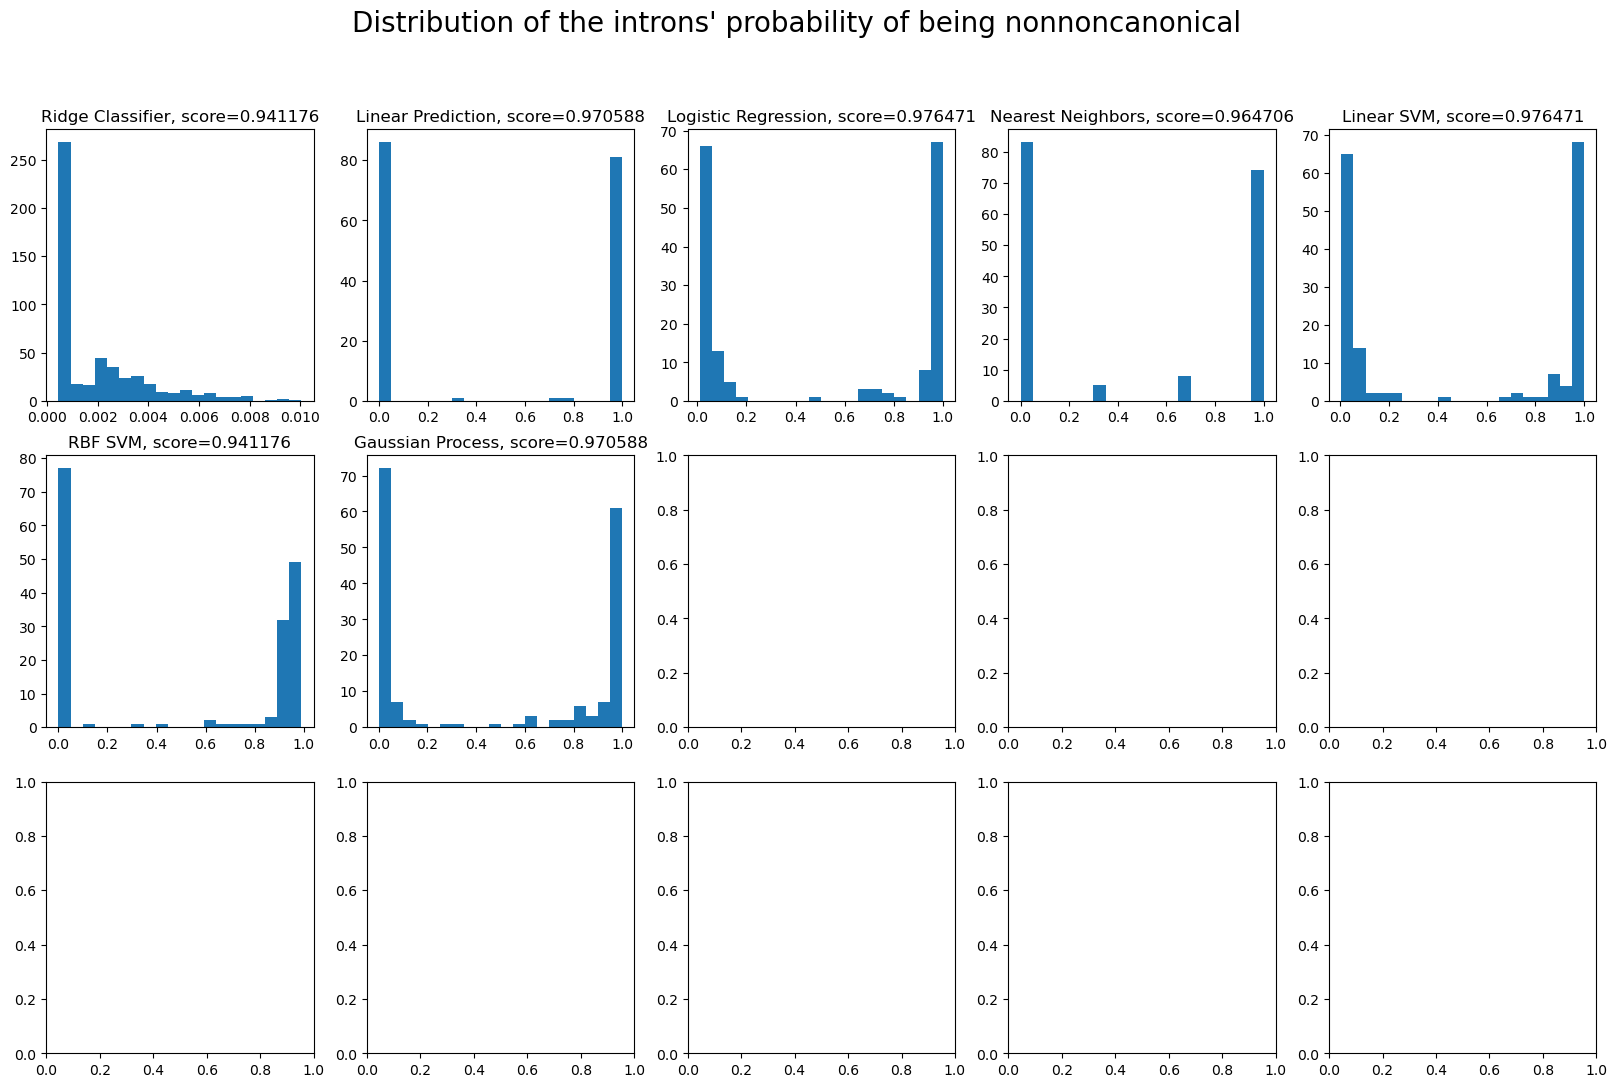

In [8]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(introns_set[columns[:-1]], introns_set[columns[-1]], random_state=123)
#X_train, X_test, y_train, y_test = train_test_split(introns_variants, true_classes, random_state=123)

fig, ax = plt.subplots(3,5, figsize=(20,12))
fig.suptitle("Distribution of the introns' probability of being nonnoncanonical", fontsize=20)
f=open("wrong_introns_wo-intermediate.fasta", 'w')

names = [
    "Ridge Classifier",
    "Linear Prediction",
    "Logistic Regression",
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    RidgeClassifier(),
    SGDClassifier(loss='log_loss'),
    LogisticRegression(random_state=0),
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, probability=True),
    SVC(gamma=2, C=1, probability=True),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

wagi_cech = []
zle_zaklasyfikowane_introny={}

for idx, clfs in list(enumerate(list(zip(names, classifiers))))[:7]:
    i_ax = ax.reshape(1,-1)[0,idx]
    clf_name, clf = clfs
    #print("\n", clf_name)
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    if hasattr(clf, "coef_"):
        print(clf_name, "has coef")
        wagi_cech.append((clf_name, clf.coef_))
    if hasattr(clf, "predict_proba"):
        print(clf_name, "has proba")
        probs = clf.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        print(clf_name, "has decision function")
        d = clf.decision_function(X_train)
        probs = np.exp(d) / np.sum(np.exp(d))
    i_ax.hist(probs, bins=20)
    i_ax.set_title("%s, score=%f" %(clf_name, score))
    #print(score)
    
    prediction = clf.predict(X_test)
    wrong_introns = introns_obj.iloc[y_test.index[prediction != y_test].tolist()]
    wrong_labels = prediction[prediction != y_test]

    for wi, lb in zip(wrong_introns,wrong_labels):
        s = wi.prev_exon.sequence[-10:] + wi.sequence + wi.next_exon.sequence[:10]
        knk = "NK" if lb == 1 else "K/I"
        f.write(">%s||%s manual: %s predicted: %s\n%s\n" %(clf_name, wi.__str__(), wi.man_annotation, knk, s))
    
f.close()
#plt.savefig("przewidziane_pstwo_12.png", format='png', transparent=False)
#plt.show()

In [9]:
'''Cross-validation, wybór najlepszego klasyfikatora'''
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, make_scorer

X, y = introns_set[columns[:-1]], introns_set[columns[-1]]

trained_classificators={}

for idx, clfs in enumerate(list(zip(names, classifiers))):
    clf_name, clf = clfs
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    #score = cross_val_score(clf, X, y, scoring=, cv=10)
    #print(clf_name, sum(score)/len(score), "accuracy: %f, f-score: %f" %())
    print(clf_name,"accuracy: %f, f-score: %f" %(accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)))
    trained_classificators[clf_name] = clf

Ridge Classifier accuracy: 0.941176, f-score: 0.938272
Linear Prediction accuracy: 0.976471, f-score: 0.976190
Logistic Regression accuracy: 0.976471, f-score: 0.976190
Nearest Neighbors accuracy: 0.964706, f-score: 0.963855
Linear SVM accuracy: 0.976471, f-score: 0.976190
RBF SVM accuracy: 0.941176, f-score: 0.943182
Gaussian Process accuracy: 0.970588, f-score: 0.970414
Decision Tree accuracy: 0.964706, f-score: 0.964286
Random Forest accuracy: 0.976471, f-score: 0.976471
Neural Net accuracy: 0.982353, f-score: 0.982249


/home/semik/miniconda3/envs/python310/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost accuracy: 0.976471, f-score: 0.976190
Naive Bayes accuracy: 0.952941, f-score: 0.951220
QDA accuracy: 0.947059, f-score: 0.947368


In [10]:
'''test klasyfikatorów na wszystkich intronach z wariantami'''
clf = trained_classificators["RBF SVM"]
#clf = trained_classificators.get("Gaussian process")
predictions=[]
introns_df = pd.DataFrame({"introns_obj": introns_obj, "klasa": introns_set['klasa']})
for i in list(introns_df.iterrows()):
    intron, klasa = i[1]['introns_obj'], i[1]['klasa']
    variants = [intron]+intron.variations
    v_c = pd.DataFrame([introns.compute_intron_characteristics(var) for var in variants], 
                       columns=['eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C', 'CAG - CGT', 'iY| e', 'i |Re'])
    pred_prob = np.array(clf.predict_proba(v_c))
    pred_class = np.array(clf.predict(v_c))
    #predictions.append((pred1, klasa))
    predictions.append((pred_prob, klasa))
    #print(pred_prob, pred_class, klasa)

In [11]:
s = sum([np.argmax(p[:,1])==0 if k==1 else np.argmax(p[:,0])==0 for p, k in predictions])
len(predictions), s


(680, 559)

eY| i 	 0.3988419109971286
e |Ri 	 -0.23033755348547047
C-G 	 0.43144863259013694
A-T 	 0.7308493371289392
G-C 	 -0.02177680962632682
CAG - CGT 	 0.13759721958525087
iY| e 	 0.09510823515973499
i |Re 	 0.057878281383131405


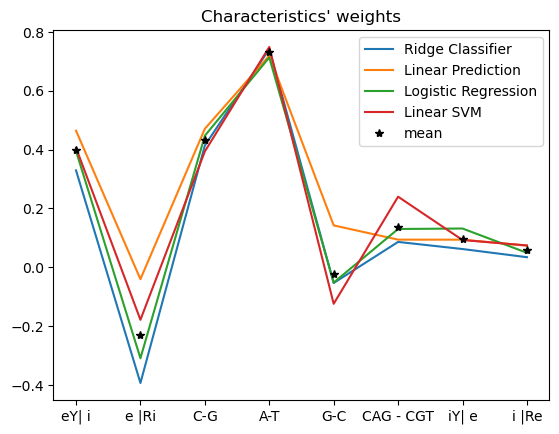

In [12]:
wagi_cech_n=[(n, w/np.linalg.norm(w)) for n, w in wagi_cech]
fig, ax = plt.subplots()
for n, i in wagi_cech_n:
    plt.plot(i[0], label=n)

ticks_loc = ax.get_xticks().tolist()
ax.set_xticks(range(len(columns)))
ax.set_xticklabels(columns)
ax.set_title("Characteristics' weights")

summed = sum([i for n,i in wagi_cech_n]).flatten()
summed = summed/(len(wagi_cech_n))#np.linalg.norm(summed)
for i in range(len(summed)):
    print(columns[i],"\t", summed[i])
plt.plot(range(len(summed)),summed , "k*", label="mean")
plt.legend()
plt.savefig("wagi_cech.png")
plt.show()

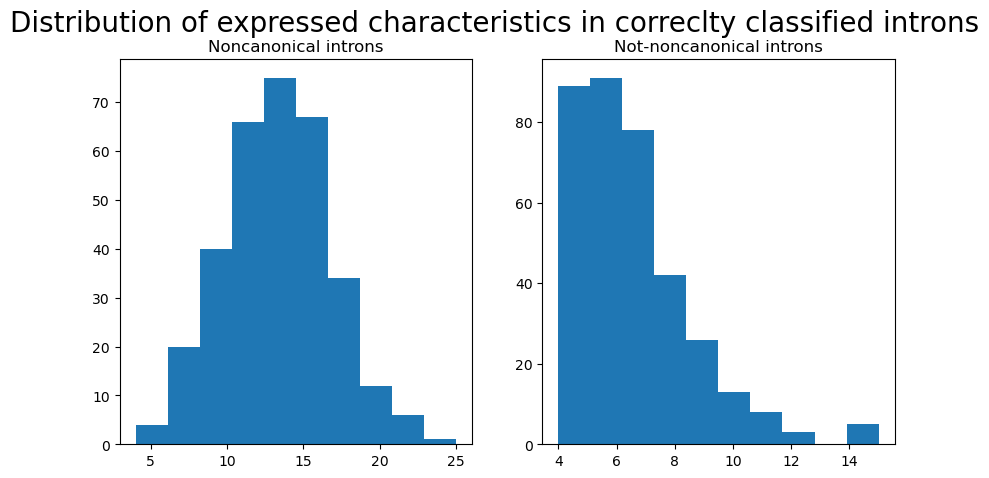

In [13]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
fig.suptitle("Distribution of expressed characteristics in correclty classified introns", fontsize=20)

introns_set['suma'] = introns_set[columns[:-1]].sum(axis=1)
ax[0].hist(introns_set['suma'][introns_set['klasa']==1])
ax[0].set_title("Noncanonical introns")
ax[1].hist(introns_set['suma'][introns_set['klasa']==0])
ax[1].set_title("Not-noncanonical introns")

plt.savefig("spelnione_cechy.png", transparent=False)

### zamach za pomoca pawla

In [14]:
df_correct = pd.DataFrame(columns=["class", "position"])
probs = [[], []]
correct_class=[]
correct_position=[]
for intron, true_class in zip(introns_variants, true_classes):
    if not intron: continue
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p = clf.predict_proba(intron)
    s = sorted(p, key = lambda x: x[0])
    max_0, max_1 = s[-1], s[0]
    if len(s)==1:
        correct_class.append(True)
        correct_position.append(True)
    
    elif (max_0[0]>max_1[1] and true_class==0):
        correct_class.append(True)
        if np.all([max_0, p[0]]): correct_position.append(True)
        else: correct_position.append(False)
        
    elif (max_0[0]<max_1[1] and true_class==1):
        correct_class.append(True)
        if np.all([max_1, p[0]]): correct_position.append(True)
        else: correct_position.append(False)
    else:
        correct_class.append(False)
        correct_position.append(False)
    df_correct = pd.concat([df_correct, pd.Series(correct_class, correct_position)], ignore_index=True)
print(sum(correct_class), sum(correct_position))

590 590


In [15]:
df_correct = pd.DataFrame(columns=["class", "position"])
probs = [[], []]
for intron, true_class in list(zip(introns_variants, true_classes))[:5]:
    correct_class=None
    correct_position=None
    
    if not intron: continue
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p = clf.predict_proba(intron)
    probs = [j for _,j in p]
    s = sorted(probs)
    max_0, max_1 = s[0], s[-1]
    print(max_0, max_1)
    
    if len(s)==1:
        correct_position=True
        if probs.index(max_0)==0 and true_class==0: correct_position=True
        elif probs.index(max_1)==1 and true_class==0: correct_position=True
        else: correct_position=False
    
    
    df_correct = pd.concat([df_correct, pd.Series([correct_class, correct_position])], ignore_index=True)

0.9679500075656156 0.9679500075656156
0.8795206112078859 0.9326040141765669
0.8324945799588589 0.9928132048961689
0.986038641020642 0.986038641020642
0.8953671815506535 0.9286099502493258


In [16]:
print(sum(correct_class), sum(correct_class)/len(correct_class))
print(sum(correct_position), sum(correct_position)/len(correct_position))

df = pd.DataFrame(columns=["class", "position"])
df['class'] = correct_class
df['position'] = correct_position

TypeError: 'NoneType' object is not iterable